# FWI com Unets

In [ ]:
# %env XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2

In [1]:
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import clear_output


import numpy as np

import tensorflow as tf
from tensorflow.keras import  layers, Model

from geod67lib.unet import create_migration_map
from geod67lib.normalization import create_normalization_transforms
from geod67lib.plotting import plot_image, plot_seismogram
from geod67lib.wavefield import AquisitionParameters, generate_damp_mask
from geod67lib.wavefield.keras import WaveSolverLayer, MigFWIDataset, MSECossineSimilarityLoss



2026-07-08 07:56:24.485662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Modelo de velocidade e imagem migrada

In [2]:
# shape = (1024, 512)
# shape = (256, 256)
# spacing = (10, 10)
shape = (128, 128)
spacing = (20, 20)

width, height = (shape[0] - 1)*spacing[0], (shape[1] - 1)*spacing[1]

In [3]:
vp_true = np.fromfile(f'./data/marmo_vp_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
vp_0 = np.fromfile(f'./data/vp0_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
zeta = np.fromfile(f'./data/mig_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))

In [4]:
vpmin = vp_true.min()*.9
vpmax = vp_true.max()*1.1

vpmin, vpmax

(np.float32(1.3499999), np.float32(4.895))

In [5]:
normalize, denormalize = create_normalization_transforms(vpmin, vpmax)

In [6]:
m_0 = normalize(tf.constant(vp_0))

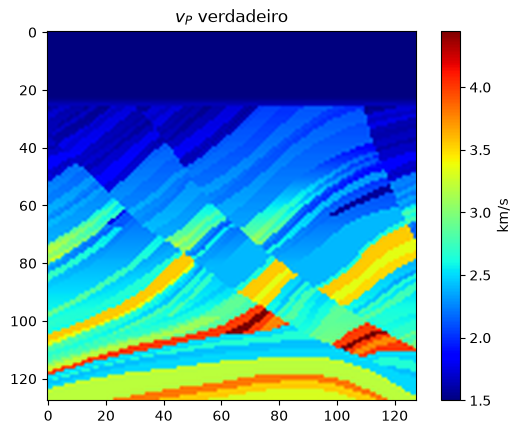

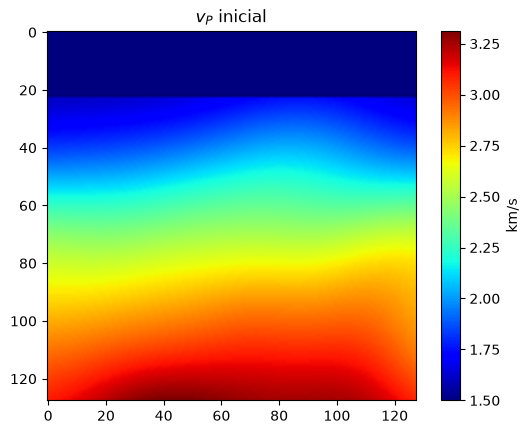

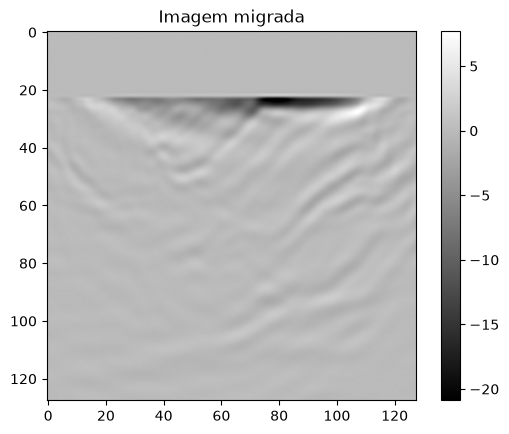

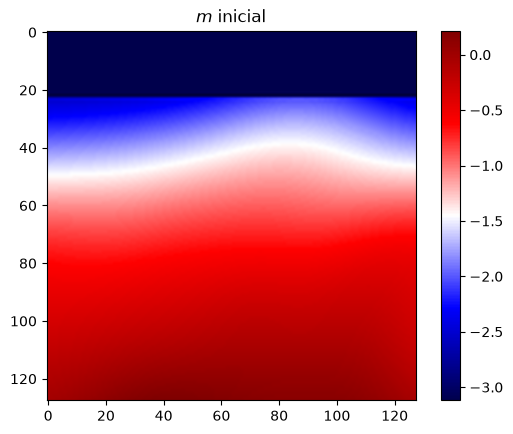

In [7]:
plot_image(vp_true, title='$v_P$ verdadeiro', label='km/s')
plot_image(vp_0, title='$v_P$ inicial', label='km/s')
plot_image(zeta, title='Imagem migrada', cmap='gray')
plot_image(m_0.numpy(), title='$m$ inicial', cmap='seismic')

## Construção da Rede

In [8]:
migmap = create_migration_map(*shape)

In [9]:
zeta_in = tf.constant(zeta)
np.min(zeta_in), np.max(zeta_in)

(np.float32(-20.882881), np.float32(7.735516))

In [10]:
dm = migmap(zeta_in)
np.min(dm), np.max(dm)

(np.float32(-1.6425803), np.float32(1.8371711))

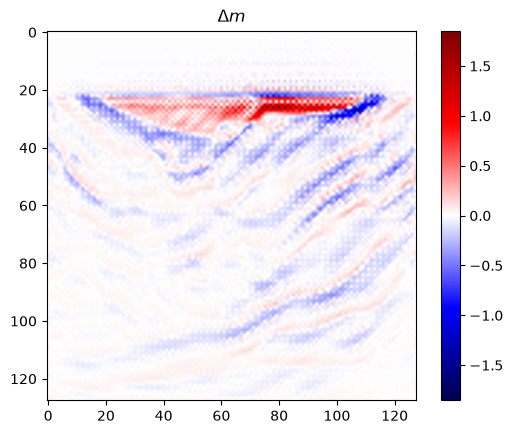

In [11]:
d = dm.numpy()
d = d - np.median(d)
plot_image(d, cmap='seismic', vmin=-np.abs(d).max(), vmax=np.abs(d).max(), title='$\\Delta m$')

## Operador de modelagem

In [12]:
nbl = 40

In [13]:
ap = AquisitionParameters.load('./data/aquisition-params.json')

nrec = ap.nrec
nsrc = ap.nsrc
nt = ap.nt

src_positions = ap.src_positions
ap.src_positions = np.zeros((1, 2))

In [14]:
vp0_pad = np.pad(vp_0[0, :, :, 0], nbl, mode='edge')
vp0_pad = vp0_pad.reshape((1, *vp0_pad.shape, 1))
damp_mask = generate_damp_mask(vp0_pad, nbl)
water_mask = np.fromfile(f'data/watermask_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.int8).reshape(1, *shape, 1)

In [15]:
damp_mask.shape

(1, 208, 208, 1)

## Dado observado

In [16]:
dobs = np.fromfile(f'./data/dobs_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape(nsrc, nrec, nt)

In [17]:
slider = widgets.IntSlider(min=0, max=nsrc-1, description='Shot index')
@widgets.interact(idx=slider)
def plot_seismogram_interact(idx):
    clear_output()
    plot_seismogram(dobs[idx], width, ap.tn)

interactive(children=(IntSlider(value=0, description='Shot index', max=4), Output()), _dom_classes=('widget-in…

## Inversão

In [18]:
input_src = layers.Input(shape=(2,), name='in_src')
input_zeta = layers.Input(shape=(*shape, 1), name='in_zeta')

dm = migmap(input_zeta)
m = layers.Add()([dm, m_0])
vp_full = layers.Lambda(denormalize)(m)
vp_full =layers.Reshape((-1,))(vp_full)
src_pos = layers.Reshape((-1,))(input_src)
src_vp = layers.Concatenate(axis=-1)([src_pos, vp_full])
wsl = WaveSolverLayer(ap, damp_mask, water_mask, spacing=spacing, shape=shape, fd_order=4,)
out = wsl(src_vp)
out

<KerasTensor shape=(None, 128, 1500), dtype=float32, sparse=False, ragged=False, name=keras_tensor_40>

In [19]:
model = Model(inputs=[input_src, input_zeta],outputs=out,name='train_net')
# model = Model(inputs=[input_src, input_zeta] ,outputs=src_vp,name='train_net')
model

<Functional name=train_net, built=True>

In [ ]:
# model.load_weights('./data/it1500nbl40.weights.h5')

In [ ]:
plot_image(denormalize(migmap(zeta) + m_0).numpy())

In [ ]:
with tf.GradientTape() as g:
    dcalc = model((src_positions[0:1], np.zeros_like(zeta)))
    res = dcalc - dobs[0]
    phi = tf.reduce_mean(tf.square(res))

    grad = g.gradient(phi, model.variables[0])
grad

In [ ]:
plot_seismogram(dobs[0], width, ap.tn)
plot_seismogram(dcalc[0], width, ap.tn)
plot_seismogram(dcalc[0] - dobs[0], width, ap.tn)

In [20]:
learning_rate = 1e-3

In [21]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError,
    # loss=MSECossineSimilarityLoss(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate,),
    metrics=[
        tf.keras.metrics.MeanSquaredError()
    ]
)

In [ ]:
zeta.shape

In [ ]:
dataset = MigFWIDataset(src_positions, zeta.reshape((zeta.shape[1], zeta.shape[2], 1)), dobs, 5)

In [ ]:
# x_train = zeta
# y_train = dobs.reshape((1, *dobs.shape))

In [ ]:
cb_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    monitor='loss',
    filepath='./data/migmap.weights.h5',
    save_best_only=True,
    save_weights_only=True,
)

cb_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    patience=100
)

In [ ]:
history = model.fit(
    # x_train,
    # y_train,
    dataset,
    batch_size=dataset.batch_size,
    # verbose=2,
    epochs=100,
    callbacks=[ cb_checkpoint, cb_earlystop ]
)

In [ ]:
dataset[0][0][0].shape

In [ ]:
history.history['loss']

In [ ]:
model.metrics

In [22]:
model.load_weights('./data/it1500nbl40-prelu.weights.h5')

/home/filipe.nolasco/.conda/envs/geod67-unet-fwi/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 76 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [23]:
dm = migmap(zeta)

In [ ]:
# plot_image(m_0.numpy(), cmap='seismic')
# plot_image(dm.numpy() * water_mask, cmap='seismic', vmax=-tf.reduce_min(dm), vmin=tf.reduce_min(dm))
# plot_image((m_0 + dm).numpy()* water_mask + (1 - water_mask) * 1.5, cmap='seismic', vmax=tf.reduce_max(m_0 + dm), vmin=-tf.reduce_max(m_0 + dm))

In [ ]:
# for v in migmap.variables:
#     if v.path.startswith('p_re_lu'):
#         print(v)

In [24]:
a = denormalize(dm + m_0).numpy() * water_mask + (1 - water_mask) * 1.5

In [25]:
tf.reduce_mean(
    tf.square(a - vp_true)
)

<tf.Tensor: shape=(), dtype=float64, numpy=0.05747607212762063>

In [26]:
tf.reduce_mean(
    tf.square(vp_0 - vp_true)
)

<tf.Tensor: shape=(), dtype=float32, numpy=0.10679031908512115>

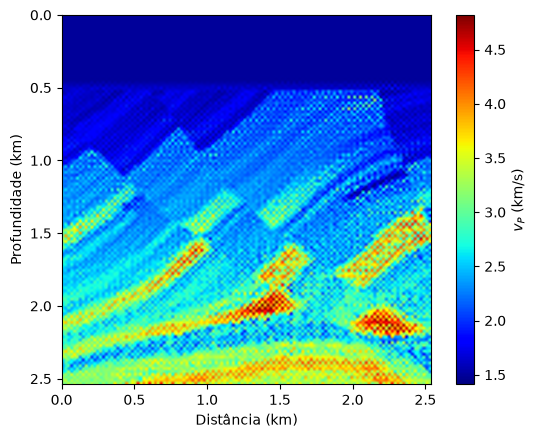

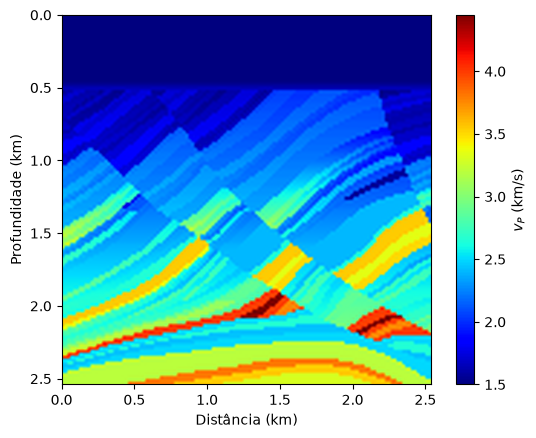

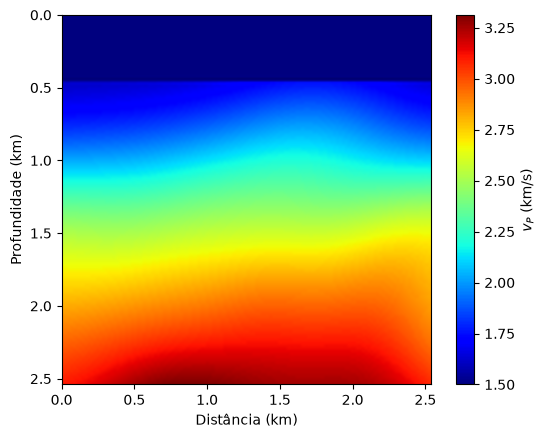

In [29]:
plot_image(denormalize(dm + m_0).numpy() * water_mask + (1 - water_mask) * 1.5, width=width/1e3, height=height/1e3, xlabel='Distância (km)', ylabel='Profundidade (km)', label='$v_P$ (km/s)')
plot_image(vp_true, width=width/1e3, height=height/1e3, xlabel='Distância (km)', ylabel='Profundidade (km)', label='$v_P$ (km/s)')
plot_image(vp_0, width=width/1e3, height=height/1e3, xlabel='Distância (km)', ylabel='Profundidade (km)', label='$v_P$ (km/s)')

In [ ]:
dcalc = history.model((src_positions[2:3], np.zeros_like(zeta)))